# LLM-классификация типа работ для публикаций

Использую языковую модель (GPT-4o-mini через OpenAI API) для классификации каждой публикации по типу работ

Входные данные: `data_processed/marker_results_main_clean.csv`  
Выходные данные: `data_processed/marker_results_classified.csv`

Переменные окружения:
- `LLM_API_KEY` — ключ OpenAI
- `LLM_API_BASE` — базовый URL (`https://api.openai.com/v1`)
- `LLM_MODEL` — модель (`gpt-4o-mini`)

In [ ]:
import json, time, re, ssl
import pandas as pd
import urllib.request
from pathlib import Path

# на macOS SSL-сертификаты иногда не находятся — отключаем проверкуssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode = ssl.CERT_NONE

INP = Path("data_processed") / "marker_results_main_clean.csv"
OUT = Path("data_processed") / "marker_results_classified.csv"

LLM_API_KEY = ""
LLM_API_BASE = "https://api.mistral.ai/v1"
LLM_MODEL = "mistral-small-latest"

SLEEP_BETWEEN_CALLS = 0.3
MAX_RETRIES = 3
RETRY_SLEEP = 5

In [42]:
# True = включить в выборку, False = исключить
WORK_TYPE_SCHEMA = {
    "new_construction": (True,  "Новое строительство школьного здания"),
    "design_and_construction": (True,  "ПИР + СМР совмещённые (под ключ)"),
    "completion": (True,  "Завершение ранее начатого строительства школы"),
    "annex": (False, "Пристройка/расширение к существующей школе"),
    "design_only": (False, "Только проектирование и/или изыскания (без СМР)"),
    "pool_sports": (False, "Бассейн, спортзал, стадион, ледовая арена"),
    "arts_school": (False, "Детская школа искусств (не общеобразовательная)"),
    "survey_assessment": (False, "Техническое обследование, экспертиза, инспекция"),
    "small_works": (False, "Мелкие работы/поставки (ограждение, генератор, лифт и т.п.)"),
    "out_of_scope": (False, "Прочее — не относится к школьному строительству или вне ПФО"),
}
VALID_TYPES = list(WORK_TYPE_SCHEMA.keys())

Загружаю список публикаций:

In [ ]:
df = pd.read_csv(INP)
print(f"Загружено {len(df)} публикаций")

df_cls = df[[
    "registry_number",
    "publication_name",
    "publication_name_full",
    "Сфера деятельности",
    "Регион поставки",
    "customer_price_rub",
]].copy()

done = pd.DataFrame(columns=["registry_number", "work_type", "include_base", "llm_reason", "llm_raw"])
df_todo = df_cls.copy()
print(f"Осталось классифицировать: {len(df_todo)}")

Загружено 157 публикаций
Осталось классифицировать: 157


Функции для работы с API:

In [ ]:
SYSTEM_PROMPT = """Ты — эксперт по государственным закупкам в сфере строительства школ.
Твоя задача: классифицировать тендерную закупку по типу работ.

Допустимые типы (work_type):
- new_construction — новое строительство здания общеобразовательной школы
- design_and_construction — совмещённый контракт «ПИР + строительство» (под ключ) на школу
- completion — завершение ранее начатого строительства школьного здания
- annex — пристройка или дополнительный учебный корпус к существующей школе
- design_only — только проектирование и/или инженерные изыскания (без СМР)
- pool_sports — строительство бассейна, спортзала, стадиона, ледовой арены при школе
- arts_school — детская школа искусств или иное учреждение допобразования (не СОШ)
- survey_assessment — техническое обследование, экспертиза, оценка состояния здания
- small_works — мелкие работы или поставки (ограждение, лифт, генератор, септик и тп)
- out_of_scope — не относится к строительству школ или объект находится вне ПФО

Отвечай ТОЛЬКО валидным JSON без markdown-блоков:
{"work_type": "<one of the above>", "reason": "<краткое обоснование на русском, 1-2 предложения>"}"""


def build_user_message(row):
    name = str(row.get("publication_name_full", "") or row.get("publication_name", ""))
    sphere = str(row.get("Сфера деятельности", "") or "")
    region = str(row.get("Регион поставки", "") or "")
    price = row.get("customer_price_rub", None)
    price_str = f"{price:,.0f} руб." if pd.notna(price) else "неизвестна"
    return (
        f"Название публикации: {name}\n"
        f"Сфера деятельности (ОКПД2/КТРУ): {sphere}\n"
        f"Регион поставки: {region}\n"
        f"НМЦК: {price_str}\n\n"
        f"Определи work_type и кратко обоснуй."
    )


def send_to_llm(row):
    payload = json.dumps({
        "model": LLM_MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_user_message(row)},
        ],
        "temperature": 0.0,
        "max_tokens":  200,
    }).encode()

    req = urllib.request.Request(
        f"{LLM_API_BASE}/chat/completions",
        data=payload,
        headers={
            "Authorization": f"Bearer {LLM_API_KEY}",
            "Content-Type": "application/json",
        },
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=30, context=ssl_ctx) as resp:
        raw = json.loads(resp.read())

    content = raw["choices"][0]["message"]["content"]
    parsed = json.loads(re.search(r"\{.*\}", content, re.DOTALL).group())
    return {
        "work_type": parsed.get("work_type", "out_of_scope"),
        "reason": parsed.get("reason", ""),
        "raw": content,
    }


def classify_with_retry(row):
    for attempt in range(1, MAX_RETRIES + 1):
        result = send_to_llm(row)
        if result["work_type"] not in VALID_TYPES:
            result["work_type"] = "out_of_scope"
        return result
    return {"work_type": "error", "reason": "Не удалось получить ответ от LLM", "raw": ""}

Запускаю классификацию:

In [46]:
results = []
n_total = len(df_todo)

for i, (idx, row) in enumerate(df_todo.iterrows(), start=1):
    res = classify_with_retry(row)
    wt  = res["work_type"]
    inc = WORK_TYPE_SCHEMA.get(wt, (False, ""))[0]

    results.append({
        "registry_number": row["registry_number"],
        "work_type": wt,
        "include_base": inc,
        "llm_reason": res["reason"],
        "llm_raw": res["raw"],
    })

    status = "✓" if inc else "✗"
    print(f"{i:3d}/{n_total} {status} {wt:25s} | {str(row['publication_name'])}")
    time.sleep(SLEEP_BETWEEN_CALLS)

combined = pd.concat([done, pd.DataFrame(results)], ignore_index=True)
combined.to_csv(OUT, index=False)

  1/157 ✓ new_construction          | Капитальное строительство центра образования естественно-научной и технологической направленностей "Точка роста" МБОУ "Северная СОШ №2" по адресу: Оренбургская область, Северный район, с. Северное, ул. Осенняя, д. 2
  2/157 ✗ survey_assessment         | Выполнение работ по оценке технического состояния строительных несущих конструкций и коммуникаций здания (с выполнением инженерно-геологических и инженерно-геодезических изысканий объекта Муниципального бюджетного общеобразовательного учреждения "Го...
  3/157 ✓ new_construction          | Школа на 550 мест с интернатом на 140 мест в с.Акъяр Хайбуллинского района Республики Башкортостан (3 этап)
  4/157 ✓ new_construction          | Выполнение строительно-монтажных, пусконаладочных работ, поставка оборудования, неразрывно связанного с производством работ, по объекту "Строительство средней общеобразовательной школы на 640 ученических мест с детским садом на 160 мест в микрорайон...
  5/157 ✓ new_cons

Сколько публикаций вошло в каждую категорию:

In [49]:
cls = pd.read_csv(OUT)
main = pd.read_csv(INP)
merged = main.merge(cls[["registry_number", "work_type", "include_base", "llm_reason"]], on="registry_number", how="left")

for wt, grp in cls.groupby("work_type"):
    flag = "✓ включить" if grp["include_base"].iloc[0] else "✗ исключить"
    print(f"{wt:25s} {flag}  n={len(grp)}")

annex                     ✗ исключить  n=15
arts_school               ✗ исключить  n=9
completion                ✓ включить  n=1
design_and_construction   ✓ включить  n=20
new_construction          ✓ включить  n=90
pool_sports               ✗ исключить  n=12
small_works               ✗ исключить  n=9
survey_assessment         ✗ исключить  n=1


In [ ]:
n_include = cls["include_base"].sum()
n_total = len(cls)
print(f"Итого: {n_include} публикаций в базовой выборке из {n_total}")
print(f"Исключено: {n_total - n_include}")

Итого: 111 публикаций в базовой выборке из 157
Исключено: 46


Сравниваю LLM-классификацию с простым keyword-методом:

In [55]:
EXCLUDE_KEYWORDS = [
    "бассейн", "ледовая арена", "стадион", "ограждени", "навес",
    "лифт", "генератор", "септик", "оценка технического состояния",
    "детская школа искусств", "школа искусств", "обследовани",
    "монтаж лифта", "изыскани",
]

INCLUDE_KEYWORDS = [
    "строительство школ", "строительство здания школ", "строительство средней",
    "строительство общеобразовательной", "строительство объекта капитального",
    "строительно-монтажных работ", "смр", "под ключ",
]

def rule_classify(name):
    name_low = str(name).lower()
    for kw in EXCLUDE_KEYWORDS:
        if kw in name_low:
            return "exclude"
    for kw in INCLUDE_KEYWORDS:
        if kw in name_low:
            return "include"
    return "unclear"


merged["rule_verdict"] = merged["publication_name_full"].fillna(merged["publication_name"]).apply(rule_classify)
merged["llm_verdict"] = merged["include_base"].map({True: "include", False: "exclude"})

### Сравнение: правила vs LLM

In [25]:
print(pd.crosstab(merged["rule_verdict"], merged["llm_verdict"], margins=True))

llm_verdict   exclude  include  All
rule_verdict                       
exclude            28        8   36
include             3       43   46
unclear            15       60   75
All                46      111  157


In [56]:
conflicts = merged[
    ((merged["rule_verdict"] == "include") & (merged["llm_verdict"] == "exclude")) |
    ((merged["rule_verdict"] == "exclude") & (merged["llm_verdict"] == "include"))
][["registry_number", "publication_name", "work_type", "rule_verdict", "llm_verdict", "llm_reason"]]
conflicts.shape

(11, 6)

Расхождения: правила vs LLM

In [29]:
for _, r in conflicts.iterrows():
    print(f"  [{r.rule_verdict} -> {r.llm_verdict}] {r.work_type}: {str(r.publication_name)[:90]}")
    print(f"    LLM: {r.llm_reason}")
    print()

  [exclude -> include] design_and_construction: Подготовка проектной документации, выполнение инженерных изысканий и строительство объекта
    LLM: Контракт включает как проектирование (инженерные изыскания и подготовка проектной документации), так и строительство объекта, что соответствует совмещённому контракту «ПИР + строительство».

  [include -> exclude] annex: Выполнение строительно-монтажных работ по объекту "Строительство дополнительного учебного 
    LLM: Объектом закупки является строительство дополнительного учебного корпуса к существующей школе, что соответствует типу «пристройка или дополнительный учебный корпус».

  [include -> exclude] annex: Выполнение строительно-монтажных работ по объекту "Строительство дополнительного учебного 
    LLM: Объектом закупки является строительство дополнительного учебного корпуса к существующей школе, что соответствует типу «пристройка или дополнительный учебный корпус».

  [include -> exclude] annex: Выполнение строительно-монтажных рабо

Полный список публикаций с метками:

In [52]:
for _, r in merged.sort_values(["include_base", "work_type"], ascending=[False, True]).iterrows():
    flag = "✓" if r["include_base"] else "✗"
    price = f"{r['customer_price_rub']/1e6:.0f}M" if pd.notna(r['customer_price_rub']) else "?M"
    print(f"{flag} {r['work_type']:25s} |{price:>6s} | {str(r['publication_name'])[:100]}")

✓ completion                |  486M | № зз-19142-2022 Строительство объекта: "Школа в с.Ягул Завьяловского района Удмуртской Республики" (
✓ design_and_construction   |  992M | Подготовка проектной документации, выполнение инженерных изысканий и строительство объекта: «Строите
✓ design_and_construction   | 1364M | Выполнение проектно-изыскательских и строительно-монтажных работ по объекту "Школа на 1135 мест в ЖК
✓ design_and_construction   | 1364M | Выполнение проектно-изыскательских и строительно-монтажных работ по объекту "Школа на 1135 мест в ЖК
✓ design_and_construction   | 2130M | Выполнение проектно-изыскательских и строительно-монтажных работ по объекту "Школа на 1755 мест по у
✓ design_and_construction   |  638M | Выполнение работ по проектированию и строительству объекта "Строительство второго корпуса Муниципаль
✓ design_and_construction   | 1332M | Разработка проектной документации и выполнение инженерных изысканий, выполнение работ по строительст
✓ design_and_construction  

Оцениваю качество LLM-классификации и считаю F1 на однозначных случаях:

В качестве стандартного метода использую keyword-классификатор на однозначных случаях (публикации без слова unclear в rule_verdict)

In [57]:
clear = merged[merged["rule_verdict"] != "unclear"].copy()
print(f"Однозначных случаев для оценки: {len(clear)} из {len(merged)}")

Однозначных случаев для оценки: 82 из 157


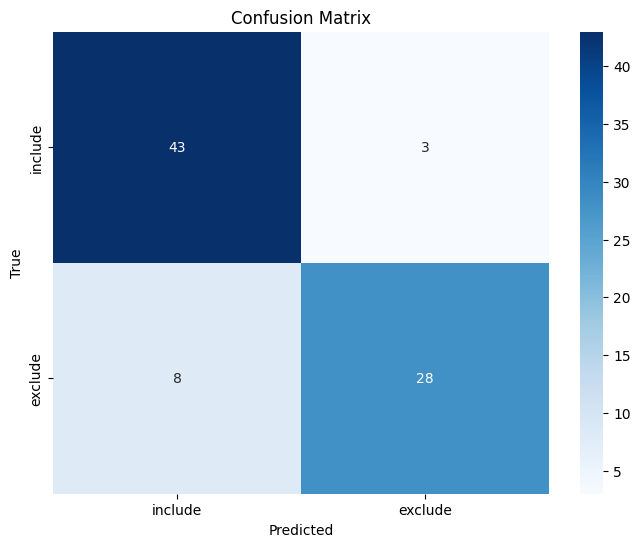

In [65]:
from sklearn.metrics import confusion_matrix

# positive class = "include"
y_true = clear["rule_verdict"].tolist()
y_pred = clear["llm_verdict"].tolist()

cm = confusion_matrix(y_true, y_pred, labels=["include", "exclude"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["include", "exclude"], 
            yticklabels=["include", "exclude"])

plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, labels=["include", "exclude"]))

              precision    recall  f1-score   support

     include       0.84      0.93      0.89        46
     exclude       0.90      0.78      0.84        36

    accuracy                           0.87        82
   macro avg       0.87      0.86      0.86        82
weighted avg       0.87      0.87      0.86        82



* LLM почти не пропускает настоящее строительство школ (только 3 из 46 правильных включений упустила)
* FP > FN — LLM скорее включает лишнее, чем пропускает нужное

H4 подтверждена

## Сравнение с TF-IDF + лог рег

Чтобы понять, дает ли LLM реальное преимущество перед классическим ML, обучаю TF-IDF + лог рег на тех же 82 однозначных публикациях

Использую Leave-One-Out Cross-Validation — каждый раз обучаю на 81 примере, предсказываю 1 оставшийся (потому что выборка маленькая)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.pipeline import Pipeline

Текст публикации как признаки, метка = rule_verdict

In [ ]:
X = clear["publication_name_full"].tolist()
y = (clear["rule_verdict"] == "include").astype(int).tolist()

In [ ]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1, max_features=3000)),
    ("lr", LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42))
])

y_pred = cross_val_predict(pipe, X, y, cv=LeaveOneOut())

p_ml, r_ml, f1_ml, _ = precision_recall_fscore_support(y, y_pred, average="binary", pos_label=1, zero_division=0)
acc_ml = accuracy_score(y, y_pred)

LLM на том же подмножестве:

In [67]:
y_llm = (clear["llm_verdict"] == "include").astype(int).tolist()
p_llm, r_llm, f1_llm, _ = precision_recall_fscore_support(y, y_llm, average="binary", pos_label=1, zero_division=0)
acc_llm = accuracy_score(y, y_llm)

print(f"{'Метод':<30} {'Precision':>9} {'Recall':>9} {'F1':>9} {'Accuracy':>9}")
print("-" * 70)
print(f"{'TF-IDF + LR (LOO-CV)':<30} {p_ml:>9.3f} {r_ml:>9.3f} {f1_ml:>9.3f} {acc_ml:>9.3f}")
print(f"{'LLM zero-shot (Mistral)':<30} {p_llm:>9.3f} {r_llm:>9.3f} {f1_llm:>9.3f} {acc_llm:>9.3f}")

Метод                          Precision    Recall        F1  Accuracy
----------------------------------------------------------------------
TF-IDF + LR (LOO-CV)               1.000     1.000     1.000     1.000
LLM zero-shot (Mistral)            0.843     0.935     0.887     0.866


In [69]:
print(f"Однозначных примеров: {len(y)}, include={sum(y)}, exclude={len(y)-sum(y)}")

Однозначных примеров: 82, include=46, exclude=36


**Вывод:** 

TF-IDF + lr достигает F1 = 1.000 на однозначных публикациях — он просто выучивает те же ключевые слова, на которых построен keyword-классификатор, но TF-IDF не справляется с 75 неоднозначными публикациями (48% выборки), где ключевые слова дают непонятнй сигнал или отсутствуют  

LLM классифицирует все 157 публикаций, опираясь на смысл, а не только на ключевые слова (что является преимуществом для этой задачи)

### Применение TF-IDF к неоднозначным публикациям

75 публикаций не попали ни в include, ни в exclude по ключевым словам — keyword-правило вернуло «unclear». Обучаю TF-IDF + lr на 82 чистых примерах и применяю к этим 75 + сравниваю с LLM

In [70]:
unclear = merged[merged["rule_verdict"] == "unclear"].copy().reset_index(drop=True)

X_train = clear["publication_name_full"].fillna(clear["publication_name"]).fillna("").tolist()
y_train = (clear["rule_verdict"] == "include").astype(int).tolist()
X_test  = unclear["publication_name_full"].fillna(unclear["publication_name"]).fillna("").tolist()

pipe_full = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1, max_features=3000)),
    ("lr",    LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42))
])
pipe_full.fit(X_train, y_train)
unclear["tfidf_verdict"] = ["include" if p == 1 else "exclude" for p in pipe_full.predict(X_test)]

agree    = (unclear["tfidf_verdict"] == unclear["llm_verdict"]).sum()
disagree = len(unclear) - agree
print(f"Согласие TF-IDF и LLM на 75 unclear-публикациях: {agree}/{len(unclear)} ({agree/len(unclear)*100:.0f}%)")
print(f"Расхождений: {disagree}")

Согласие TF-IDF и LLM на 75 unclear-публикациях: 50/75 (67%)
Расхождений: 25


In [72]:
print(pd.crosstab(unclear["tfidf_verdict"], unclear["llm_verdict"]))

llm_verdict    exclude  include
tfidf_verdict                  
exclude             11       21
include              4       39


Конкретные расхождения:

In [73]:
rows = unclear[unclear["tfidf_verdict"] != unclear["llm_verdict"]].copy()
print(f"Расхождений - {len(rows)} публикаций")

Расхождений - 25 публикаций


In [74]:
for _, r in rows.iterrows():
    name = str(r.get("publication_name_full", r["publication_name"]))[:120]
    print(f"  TF-IDF={r['tfidf_verdict']:7s} | LLM={r['llm_verdict']} | {name}")

  TF-IDF=exclude | LLM=include | Капитальное строительство центра образования естественно-научной и технологической направленностей "Точка роста" МБОУ "С
  TF-IDF=exclude | LLM=include | Выполнение работ по строительству объекта «Общеобразовательная школа в квартале № 23 южной части жилого района «Затон-Во
  TF-IDF=exclude | LLM=include | ОК-№-1572/22 «выполнение работ по строительству объекта капитального строительства "Общеобразовательная школа в микрорай
  TF-IDF=include | LLM=exclude | Строительство дополнительного учебного корпуса для МОУ «СОШ №20 им. М.И. Кулькиной» по адресу: Саратовская область, г. Э
  TF-IDF=include | LLM=exclude | Строительство детской школы искусств в с.Лобаново
  TF-IDF=include | LLM=exclude | Строительство детской школы искусств в с.Кочево
  TF-IDF=include | LLM=exclude | ВЫПОЛНЕНИЕ РАБОТ ПО ОБЪЕКТУ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА: «СТРОИТЕЛЬСТВО ДЕТСКОЙ ШКОЛЫ ИСКУССТВ В С. КОЧЕВО»
  TF-IDF=exclude | LLM=include | Выполнение работ по строительству объекта капит

**Выводы:**

- TF-IDF=exclude, LLM=include (21 случай): шаблон «выполнение работ по строительству объекта КС в сфере образования «Школа на N мест»» TF-IDF не видел в обучающей выборке — он классифицирует по близости к уже известным шаблонам и ошибается. LLM понимает, что «объект в сфере образования = Школа» — это школьное строительство

- TF-IDF=include, LLM=exclude (4 случая): «Детская школа искусств» и «дополнительный учебный корпус» содержат слово «строительство», поэтому TF-IDF включает, а LLM читает смысл и правильно исключает - это не общеобразовательная школа

Итого: 25 из 75 неоднозначных случаев (33%) — это ситуации, где TF-IDF экстраполирует по поверхностным признакам, а LLM опирается на смысловой контекст, поэтому LLM лучше подходит для классификации